# Titration Lab: How Strong Is My Acid?
### A short, conceptual acid-base titration problem - worked out, drawn and plotted in Python

---

## The problem

A student pipettes **25.00 mL of hydrochloric acid** of unknown concentration into
a conical flask, adds **two drops of phenolphthalein**, and titrates it against
**0.100 M sodium hydroxide** delivered from a 50 mL burette.

$$\mathrm{HCl(aq)} + \mathrm{NaOH(aq)} \longrightarrow \mathrm{NaCl(aq)} + \mathrm{H_2O(l)}$$

The flask is swirled over a white tile, and the very first permanent pale-pink
tinge is taken as the endpoint.

| burette reading | volume |
|---|---|
| initial | 0.40 mL |
| final (first permanent pink) | 23.90 mL |

**Questions**

**(a)** What volume of NaOH was delivered, and what is the concentration of the HCl?

**(b)** What is the pH at the equivalence point? Why?

**(c)** The student repeats the experiment but this time squirts ~25 mL of
distilled water into the flask **before** starting. Does the titre change?

**(d)** Would methyl orange have worked just as well as phenolphthalein here?

Take a moment to answer them in your head before scrolling - (c) is the one that
catches almost everybody.


---

## Part (a) - the arithmetic, done slowly

A titration calculation is always the same three-step walk:

1. **Titrant:** moles of the thing you *know* (the NaOH in the burette).
2. **Bridge:** use the balanced equation's mole ratio to cross over.
3. **Analyte:** divide by the volume in the flask to get its concentration.

Here the equation is 1 : 1, so step 2 is a freebie - which is exactly why this is
the first titration everybody meets.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, FancyBboxPatch, Circle

plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                     "font.family": "DejaVu Sans"})

# ---- the raw laboratory numbers -----------------------------------------
V_ACID        = 25.00     # mL of HCl pipetted into the flask
C_BASE        = 0.100     # mol/L, the standard NaOH in the burette
BURETTE_START = 0.40      # mL
BURETTE_END   = 23.90     # mL

# ---- step 1: the titre and the moles of titrant -------------------------
titre  = BURETTE_END - BURETTE_START            # mL of NaOH delivered
n_base = C_BASE * titre / 1000.0                # mol  (mol/L x L)

# ---- step 2: the bridge (1 mol NaOH neutralises 1 mol HCl) --------------
n_acid = n_base

# ---- step 3: back to a concentration ------------------------------------
c_acid = n_acid / (V_ACID / 1000.0)             # mol/L

print(f"titre        = {BURETTE_END:.2f} mL - {BURETTE_START:.2f} mL = {titre:.2f} mL")
print(f"n(NaOH)      = 0.100 mol/L x {titre/1000:.5f} L = {n_base*1000:.3f} mmol")
print(f"n(HCl)       = {n_acid*1000:.3f} mmol           (1 : 1 stoichiometry)")
print(f"c(HCl)       = {n_acid*1000:.3f} mmol / {V_ACID:.2f} mL = {c_acid:.4f} mol/L")
print()
print(f"ANSWER (a):  {titre:.2f} mL of NaOH;  the acid is {c_acid:.3f} M")


titre        = 23.90 mL - 0.40 mL = 23.50 mL
n(NaOH)      = 0.100 mol/L x 0.02350 L = 2.350 mmol
n(HCl)       = 2.350 mmol           (1 : 1 stoichiometry)
c(HCl)       = 2.350 mmol / 25.00 mL = 0.0940 mol/L

ANSWER (a):  23.50 mL of NaOH;  the acid is 0.094 M


### Why we subtract the readings

A burette is not a measuring cylinder - it tells you *where the liquid surface
is*, not how much you have poured out. The volume delivered is always
**final minus initial**, which is why a titration is unbothered by starting at
0.40 mL instead of exactly 0.00 mL. (Never top the burette up mid-titration for
the same reason it does not matter: only the difference counts.)

### One-line sanity check

0.094 M is just under 0.100 M, and the titre (23.50 mL) is just under the 25.00 mL
you would need for an exactly-0.100 M acid. The numbers hang together.

---

## The apparatus

Before the answers to (b)-(d), here is the set-up, drawn from scratch with nothing
but matplotlib rectangles, polygons and circles - burette barrel, engraved scale,
blue titrant with a proper concave meniscus, stopcock, jet tip, pink analyte in a
conical flask, white tile and retort stand.


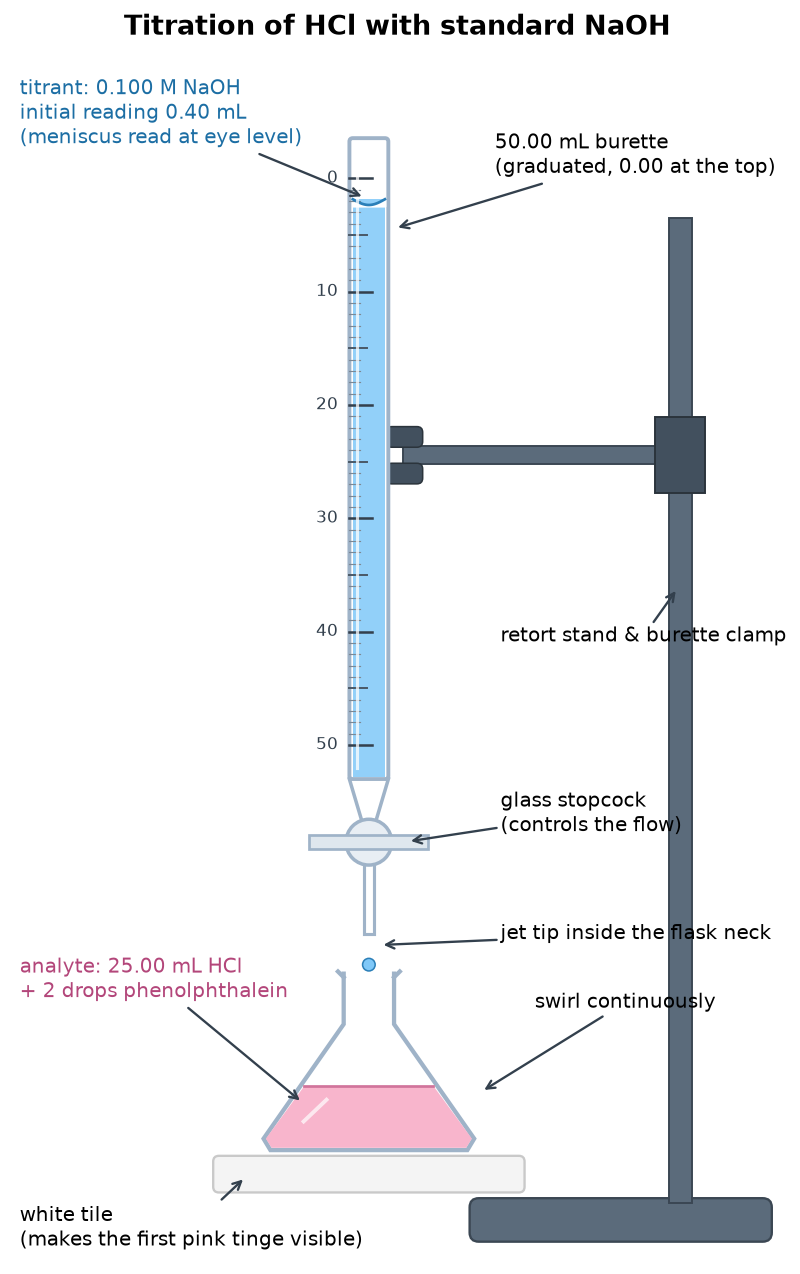

In [5]:
def draw_setup(fill_frac: float = 0.965, save: str | None = None):
    """Draw a labelled titration set-up: stand, clamp, filled burette, flask.

    fill_frac : how full the burette looks (0 = empty, 1 = up to the 0.00 mark)
    """
    fig, ax = plt.subplots(figsize=(7.2, 9.2))
    ax.set_xlim(-3.1, 3.6)
    ax.set_ylim(-0.9, 9.6)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_facecolor("white")

    GLASS = "#9fb3c8"
    TITRANT = "#7fc8f8"
    ANALYTE = "#f7a8c4"
    STEEL = "#5b6b7b"

    # ---------------- retort stand -------------------------------------
    ax.add_patch(FancyBboxPatch((0.9, -0.72), 2.6, 0.34,
                                boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=STEEL, edgecolor="#3b4753", lw=1.2,
                                zorder=1))
    ax.add_patch(Rectangle((2.62, -0.4), 0.20, 8.6, facecolor=STEEL,
                           edgecolor="#3b4753", lw=1.0, zorder=1))
    # clamp arm + boss head
    ax.add_patch(Rectangle((0.30, 6.05), 2.36, 0.16, facecolor=STEEL,
                           edgecolor="#3b4753", lw=1.0, zorder=3))
    ax.add_patch(Rectangle((2.50, 5.80), 0.44, 0.66, facecolor="#42505e",
                           edgecolor="#2b343c", lw=1.0, zorder=4))
    # jaws gripping the burette
    for dy in (-0.13, 0.19):
        ax.add_patch(FancyBboxPatch((0.16, 6.02 + dy), 0.30, 0.16,
                                    boxstyle="round,pad=0.01,rounding_size=0.05",
                                    facecolor="#42505e", edgecolor="#2b343c",
                                    lw=0.8, zorder=4))

    # ---------------- burette barrel -----------------------------------
    bx, bw = -0.17, 0.34            # left edge, width
    y_top, y_bot = 8.90, 3.30       # barrel
    ax.add_patch(FancyBboxPatch((bx, y_bot), bw, y_top - y_bot,
                                boxstyle="round,pad=0.0,rounding_size=0.03",
                                facecolor="white", edgecolor=GLASS, lw=2.0,
                                zorder=5))

    # graduated scale: 0.00 mL at the top, 50 mL at the bottom of the barrel
    y0, y50 = 8.55, 3.60
    for mL in range(0, 51):
        y = y0 + (y50 - y0) * mL / 50.0
        if mL % 10 == 0:
            ax.plot([bx, bx + 0.20], [y, y], color="#33404d", lw=1.3, zorder=8)
            ax.text(bx - 0.10, y, f"{mL}", ha="right", va="center",
                    fontsize=8.5, color="#33404d", zorder=8)
        elif mL % 5 == 0:
            ax.plot([bx, bx + 0.15], [y, y], color="#4a5866", lw=1.0, zorder=8)
        else:
            ax.plot([bx, bx + 0.09], [y, y], color="#7b8895", lw=0.6, zorder=8)

    # ---------------- titrant inside the burette -----------------------
    y_men = y_bot + fill_frac * (y0 - y_bot)          # meniscus height
    ax.add_patch(Rectangle((bx + 0.03, y_bot + 0.02), bw - 0.06,
                           y_men - y_bot - 0.02, facecolor=TITRANT,
                           edgecolor="none", alpha=0.85, zorder=6))
    # concave meniscus
    xm = np.linspace(bx + 0.03, bx + bw - 0.03, 60)
    dip = 0.05 * np.cos(np.pi * (xm - bx - bw / 2) / (bw - 0.06))
    ax.fill_between(xm, y_men - 0.06, y_men - dip, color="white", zorder=7)
    ax.plot(xm, y_men - dip, color="#2b7fb8", lw=1.4, zorder=8)
    # glass highlight
    ax.plot([bx + 0.07, bx + 0.07], [y_bot + 0.1, y_top - 0.15],
            color="white", lw=1.6, alpha=0.75, zorder=8)

    # ---------------- stopcock + delivery tip --------------------------
    ax.add_patch(Polygon([[bx, y_bot], [bx + bw, y_bot],
                          [bx + bw / 2 + 0.045, y_bot - 0.42],
                          [bx + bw / 2 - 0.045, y_bot - 0.42]],
                         closed=True, facecolor="white", edgecolor=GLASS,
                         lw=1.8, zorder=5))
    ax.add_patch(Circle((0.0, y_bot - 0.55), 0.20, facecolor="#e8eef4",
                        edgecolor=GLASS, lw=1.8, zorder=6))
    ax.add_patch(Rectangle((-0.52, y_bot - 0.61), 1.04, 0.12,
                           facecolor="#dfe7ee", edgecolor=GLASS, lw=1.4,
                           zorder=7))
    ax.add_patch(Rectangle((-0.045, y_bot - 1.35), 0.09, 0.72,
                           facecolor="white", edgecolor=GLASS, lw=1.6, zorder=5))
    # a drop on its way down
    ax.add_patch(Circle((0.0, y_bot - 1.62), 0.055, facecolor=TITRANT,
                        edgecolor="#2b7fb8", lw=0.8, zorder=6))

    # ---------------- conical (Erlenmeyer) flask -----------------------
    neck_w, neck_top, neck_bot = 0.22, 1.62, 1.16
    body_w, base_y = 0.92, 0.06
    flask = [(-neck_w, neck_top), (-neck_w, neck_bot), (-body_w, base_y + 0.10),
             (-body_w + 0.06, base_y), (body_w - 0.06, base_y),
             (body_w, base_y + 0.10), (neck_w, neck_bot), (neck_w, neck_top)]
    ax.add_patch(Polygon(flask, closed=False, facecolor="white",
                         edgecolor=GLASS, lw=2.2, zorder=5))
    ax.plot([-neck_w - 0.05, -neck_w], [neck_top, neck_top - 0.05],
            color=GLASS, lw=2.2, zorder=5)
    ax.plot([neck_w + 0.05, neck_w], [neck_top, neck_top - 0.05],
            color=GLASS, lw=2.2, zorder=5)

    # pink analyte: the level follows the cone
    lev = 0.62
    half = body_w - (body_w - neck_w) * (lev - base_y) / (neck_bot - base_y)
    soln = [(-body_w + 0.02, base_y + 0.10), (-body_w + 0.07, base_y + 0.02),
            (body_w - 0.07, base_y + 0.02), (body_w - 0.02, base_y + 0.10),
            (half, lev), (-half, lev)]
    ax.add_patch(Polygon(soln, closed=True, facecolor=ANALYTE, edgecolor="none",
                         alpha=0.85, zorder=6))
    ax.plot([-half, half], [lev, lev], color="#d1749b", lw=1.4, zorder=7)
    ax.plot([-body_w + 0.35, -body_w + 0.55], [base_y + 0.25, lev - 0.12],
            color="white", lw=2.0, alpha=0.7, zorder=8)

    # ---------------- white tile ---------------------------------------
    ax.add_patch(FancyBboxPatch((-1.35, -0.30), 2.70, 0.30,
                                boxstyle="round,pad=0.01,rounding_size=0.05",
                                facecolor="#f4f4f4", edgecolor="#c9c9c9",
                                lw=1.2, zorder=3))

    # ---------------- labels -------------------------------------------
    lab = dict(fontsize=10.5, va="center", zorder=10)
    arrow = dict(arrowstyle="->", color="#33404d", lw=1.2,
                 shrinkA=0, shrinkB=4)

    ax.annotate("50.00 mL burette\n(graduated, 0.00 at the top)",
                xy=(bx + bw + 0.02, 8.10), xytext=(1.10, 8.75),
                arrowprops=arrow, ha="left", **lab)
    ax.annotate(f"titrant: {C_BASE:.3f} M NaOH\ninitial reading 0.40 mL\n(meniscus read at eye level)",
                xy=(bx + bw / 2, y_men), xytext=(-3.05, y_men + 0.75),
                arrowprops=arrow, ha="left", color="#1c6ea4", **lab)
    ax.annotate("glass stopcock\n(controls the flow)",
                xy=(0.30, y_bot - 0.55), xytext=(1.15, y_bot - 0.30),
                arrowprops=arrow, ha="left", **lab)
    ax.annotate("jet tip inside the flask neck",
                xy=(0.06, y_bot - 1.45), xytext=(1.15, y_bot - 1.35),
                arrowprops=arrow, ha="left", **lab)
    ax.annotate(f"analyte: {V_ACID:.2f} mL HCl\n+ 2 drops phenolphthalein",
                xy=(-0.55, 0.45), xytext=(-3.05, 1.55),
                arrowprops=arrow, ha="left", color="#b3467a", **lab)
    ax.annotate("white tile\n(makes the first pink tinge visible)",
                xy=(-1.05, -0.15), xytext=(-3.05, -0.62),
                arrowprops=arrow, ha="left", **lab)
    ax.annotate("retort stand & burette clamp",
                xy=(2.72, 5.0), xytext=(1.15, 4.55),
                arrowprops=arrow, ha="left", **lab)
    ax.annotate("swirl continuously",
                xy=(0.95, 0.55), xytext=(1.45, 1.35),
                arrowprops=arrow, ha="left", **lab)

    ax.set_title("Titration of HCl with standard NaOH", fontsize=14,
                 fontweight="bold", pad=12)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150, bbox_inches="tight")
    return fig, ax

fig, ax = draw_setup()
plt.show()


### Reading it properly (the bit that costs marks in a real lab)

* **Eye level, bottom of the meniscus.** Looking down inflates the reading,
  looking up deflates it - that is *parallax* error.
* **Two decimal places, always** - a 50 mL burette reads to $\pm0.05$ mL, so
  `23.90` is honest and `23.9` throws information away.
* **The tip must be inside the flask neck**, and it must be full of liquid with no
  air bubble; a bubble that escapes mid-titration adds phantom volume.
* **White tile** so the first faint pink is visible; **swirl constantly** so a
  local excess of base does not flash pink and fool you.
* The endpoint is *one drop* - about 0.05 mL. Slow to a dropwise addition as soon
  as the pink starts to linger.

---

## Part (b) - the pH at the equivalence point

At equivalence, every mole of H⁺ has met a mole of OH⁻. What is left in the flask
is Na⁺, Cl⁻ and water. Na⁺ is the cation of a strong base and Cl⁻ is the anion of
a strong acid, so **neither of them hydrolyses**. Nothing is left to nudge the
balance either way:

$$\mathrm{pH} = 7.00 \quad (25^\circ\mathrm{C})$$

That is special to **strong acid + strong base**. Titrate a *weak* acid instead
(ethanoic acid, say) and the equivalence point lands in basic territory, pH ≈ 8-9,
because the conjugate base left behind does hydrolyse.


equivalence volume predicted from c(HCl): 23.50 mL   (measured titre 23.50 mL)
  at  23.45 mL  ->  pH  4.00
  at  23.49 mL  ->  pH  4.77
  at  23.55 mL  ->  pH 10.03


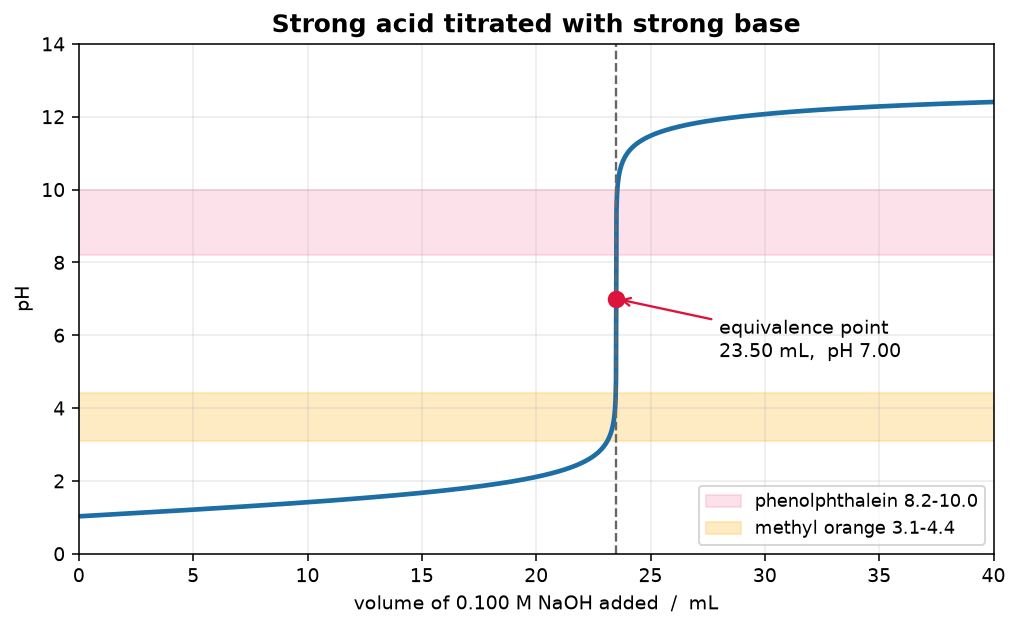

In [7]:
def ph_curve(c_acid: float, v_acid: float = V_ACID, c_base: float = C_BASE,
             v_max: float = 40.0, n: int = 2000):
    """Exact-enough pH curve for a strong acid titrated with a strong base.

    Everything is done by charge/mole balance on the *diluted* mixture, which is
    why the curve is symmetric about pH 7 for equal concentrations.
    """
    v = np.linspace(0.0, v_max, n)
    n_acid = c_acid * v_acid / 1000.0
    n_base = c_base * v / 1000.0
    vol_L = (v_acid + v) / 1000.0
    excess = (n_acid - n_base) / vol_L                  # + = acid left over
    ph = np.empty_like(v)
    acidic = excess > 1e-12
    basic = excess < -1e-12
    ph[acidic] = -np.log10(excess[acidic])
    ph[basic] = 14.0 + np.log10(-excess[basic])
    ph[~(acidic | basic)] = 7.0
    return v, ph


def draw_curve(c_acid: float, save: str | None = None):
    """pH curve with the equivalence point and the two indicator ranges."""
    v, ph = ph_curve(c_acid)
    v_eq = c_acid * V_ACID / C_BASE

    fig, ax = plt.subplots(figsize=(7.4, 4.6))
    ax.axhspan(8.2, 10.0, color="#f7a8c4", alpha=0.35,
               label="phenolphthalein 8.2-10.0")
    ax.axhspan(3.1, 4.4, color="#ffcf6b", alpha=0.40,
               label="methyl orange 3.1-4.4")
    ax.plot(v, ph, lw=2.4, color="#1c6ea4")
    ax.axvline(v_eq, ls="--", color="#666", lw=1.2)
    ax.plot([v_eq], [7.0], "o", ms=8, color="crimson", zorder=5)
    ax.annotate(f"equivalence point\n{v_eq:.2f} mL,  pH 7.00",
                xy=(v_eq, 7.0), xytext=(v_eq + 4.5, 5.4), fontsize=10,
                arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))
    ax.set_xlabel("volume of 0.100 M NaOH added  /  mL")
    ax.set_ylabel("pH")
    ax.set_ylim(0, 14)
    ax.set_xlim(0, 40)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_title("Strong acid titrated with strong base", fontsize=13,
                 fontweight="bold")
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=150, bbox_inches="tight")
    return fig, ax

fig, ax = draw_curve(c_acid)
plt.show()

v_eq = c_acid * V_ACID / C_BASE
print(f"equivalence volume predicted from c(HCl): {v_eq:.2f} mL"
      f"   (measured titre {titre:.2f} mL)")
v, ph = ph_curve(c_acid)
for target in (v_eq - 0.05, v_eq, v_eq + 0.05):
    i = int(np.argmin(np.abs(v - target)))
    print(f"  at {v[i]:6.2f} mL  ->  pH {ph[i]:5.2f}")


Look at what that curve is telling you: **one drop either side of equivalence
swings the pH by roughly six units.** That vertical cliff is the whole reason
titration works as a measuring technique - the indicator does not need to change
colour at exactly pH 7, it only has to change *somewhere inside the cliff*.

---

## Part (c) - the trick question

**Adding distilled water changes nothing.** The titre is fixed by the *number of
moles* of HCl sitting in the flask, and distilled water contributes no H⁺ and no
OH⁻. Diluting makes the solution weaker but not smaller in amount, so the same
23.50 mL of NaOH is still required.

In fact, adding a little water is a standard trick: a bigger volume swirls more
easily and makes the pink endpoint easier to see. What you must **never** dilute
is the **titrant** in the burette, or the pipetted volume you are relying on - the
first changes the moles per mL you are counting, the second changes the moles you
are measuring.

## Part (d) - the indicator

**Yes, methyl orange would work here** (it changes over pH 3.1-4.4) - look again
at the curve: both shaded indicator bands lie inside the vertical jump, so both
change colour within a drop of equivalence.

Phenolphthalein is *preferred* purely for human reasons: colourless → faint pink
is a much cleaner signal to the eye than red → yellow, especially against a white
tile. But if you were titrating a weak base with a strong acid, the choice would
stop being cosmetic and become compulsory - then only methyl orange sits inside
the (acidic) jump.


In [9]:
print("=" * 64)
print("ANSWER KEY")
print("=" * 64)
print(f"(a)  titre = {titre:.2f} mL NaOH   ->   c(HCl) = {c_acid:.3f} mol/L")
print( "(b)  pH = 7.00 : only Na+ and Cl- remain, and neither hydrolyses")
print( "(c)  no change : distilled water adds no moles of acid or base")
print( "(d)  yes : for strong acid + strong base the pH jump spans pH 4-10,")
print( "     so both indicators change inside it; phenolphthalein is merely")
print( "     easier to see")
print("=" * 64)


ANSWER KEY
(a)  titre = 23.50 mL NaOH   ->   c(HCl) = 0.094 mol/L
(b)  pH = 7.00 : only Na+ and Cl- remain, and neither hydrolyses
(c)  no change : distilled water adds no moles of acid or base
(d)  yes : for strong acid + strong base the pH jump spans pH 4-10,
     so both indicators change inside it; phenolphthalein is merely
     easier to see


---

## Three things worth carrying away

1. **Volume delivered = final − initial.** A burette measures a position, not an
   amount.
2. **Titrations count moles, not concentrations.** That single sentence answers
   part (c) and about half of all titration exam questions.
3. **The indicator only has to change inside the jump.** For strong-strong the
   jump is enormous and forgiving; for weak-strong it shifts, and the choice of
   indicator becomes a real decision.

*Companion file: `titration_lab.py` - the same calculations and both figures as a
plain runnable script (`python3 titration_lab.py`).*
